# 📊 INF01090 - Ciência de Dados - Classification Techniques

**Spaceship Titanic - Kaggle-Style Competition**

Spaceship Titanic (<https://www.kaggle.com/competitions/spaceship-titanic/>) is a popular Kaggle competition that challenges participants to predict whether a passenger was transported to an alternate dimension, using classification models. It is one of Kaggle’s most popular “Getting Started” challenges, designed to build practical skills in data cleaning, feature engineering, and predictive modelling.

## Key facts

- **Platform:** Kaggle
- **Launch year:** 2016
- **Original dataset:** 8,693 training passengers
- **Features:** 13 explanatory variables
- **Primary goal:** Predict whether a passenger was transported


## 📂 Dataset and Objective

The dataset describes various attributes of passengers—covering their home planet, cryosleep status, cabin, age, VIP status, and amenities usage. The task is to predict the binary outcome of whether they were transported, making it a supervised classification problem.

The file **`data_description.txt`** has the full description of each column.

## 🛠 Skills and techniques

This competition is widely used to practise:

- **Feature engineering:** handling missing data, encoding categorical variables, transforming skewed features
- **Model building:** experimenting with algorithms such as logistic regression, random forest, and gradient boosting classifiers
- **Evaluation:** models are ranked by **Accuracy** in our local competition setup


## 🎯 Assignment Goal

Your goal is to build a classification pipeline that predicts **`Transported`** for the hidden test set.

This is not only a leaderboard exercise. You should use this assignment to demonstrate that you understand:

- data cleaning for tabular data
- feature encoding and transformation
- classification modeling
- error analysis
- the effect of different design choices on predictive performance


## 📁 Files You Will Receive

You should work only with the files distributed for this lab:

- **`train_student.csv`** — training data with the target column
- **`test_student.csv`** — test data without the target column
- **`submission_template.csv`** — expected format for submission
- **`data_description.txt`** — attribute descriptions

Do **not** use Kaggle's original public test split for submission. The grading app uses a **custom hidden split** created for this class.


## 🏁 Submission and Leaderboard

Submissions are evaluated in the local grading app:

<https://lab06inf01090-puo9j5ajrfsar22xxfmeez.streamlit.app/>

The app expects a CSV file with exactly these columns:

```csv
PassengerId,prediction
8141_01,0
6034_01,0
3946_01,1
```

Rules:

- `Id` must match the IDs in **`test_student.csv`**
- `prediction` must contain one numeric prediction per row
- all test rows must be present
- predictions for `Transported` should be True or False


## 📌 What You Must Deliver

Each group must submit:

1. **A prediction file** for the leaderboard  
2. **This notebook** (completed, with code, outputs, and short explanations)  
3. **A short report section in the notebook** explaining:
   - preprocessing choices
   - feature engineering
   - model(s) tested
   - final model used
   - interpretation of the obtained score


## 👥 Group Work

- Work in groups of up to 4
- All members of the group must understand the final solution
- Use a consistent team name in the leaderboard
- The same team may submit multiple times; the leaderboard keeps the best score


## 📊 Grading Criteria

Your grade will not depend only on leaderboard position. The first three places will get additional grade.

Important:
- a top leaderboard score with poor documentation is **not enough**
- a strong notebook with solid methodology can still receive a high grade even if it is not the top-ranked solution


## 🚦 Recommended Workflow

A good workflow for this assignment is:

1. Inspect the training data
2. Identify numeric and categorical variables
3. Handle missing values
4. Encode categorical variables
5. Optionally transform skewed variables
6. Build a baseline classification model
7. Evaluate improvements using validation on the training set
8. Train your final model on the full student training set
9. Predict on `test_student.csv`
10. Submit the predictions to the leaderboard


## ⚠️ Restrictions and Good Practice

- Do not manually inspect or reconstruct the hidden target values
- Do not hard-code predictions
- Do not submit malformed files to probe the scorer
- Do not use the leaderboard as your only validation method

Recommended:
- create your own validation split from `train_student.csv`
- compare models locally before submitting
- submit only meaningful improvements


## 🧪 Suggested Experiments

You may explore ideas such as:

- dropping columns with many missing values
- imputing missing values numerically and categorically
- one-hot encoding categorical variables
- checking class balance for Transported
- trying different regularization strengths
- comparing linear and non-linear models
- checking whether some features are highly skewed


## 🧭 Starter Checklist

Before your first submission, verify that:

- [ ] `train_student.csv` loads correctly
- [ ] `test_student.csv` has the same predictor columns as expected
- [ ] your preprocessing works for both train and test
- [ ] your model produces one prediction per test row
- [ ] the output file has exactly two columns: `Id`, `prediction`
- [ ] all predictions are numeric
- [ ] all predictions are boolean (True/False)


## 🐍 Suggested Notebook Structure

You may organize your work using sections such as:

1. Data loading
2. Exploratory inspection
3. Missing-value handling
4. Feature encoding
5. Train/validation split
6. Baseline model
7. Improved model
8. Final training and test prediction
9. Submission file generation
10. Reflection


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


## 1. Load the data

Update the paths if necessary.


In [47]:
train_df = pd.read_csv("train_student.csv")
test_df = pd.read_csv("test_student.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()


Train shape: (6085, 14)
Test shape: (2608, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,3652_01,Earth,True,G/591/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,0.0,Lina Frandriquez,False
1,8449_01,Europa,False,C/317/S,55 Cancri e,32.0,False,0.0,2154.0,0.0,9655.0,859.0,Arrain Purellliss,False
2,1871_01,Europa,False,C/70/S,TRAPPIST-1e,31.0,NaN,0.0,1983.0,0.0,172.0,52.0,Aston Spedlybood,True
3,1811_01,Earth,True,G/285/S,PSO J318.5-22,25.0,False,0.0,0.0,0.0,0.0,0.0,Gerry Georgasey,True
4,8589_01,Europa,False,D/267/P,55 Cancri e,26.0,False,6.0,728.0,0.0,1273.0,1116.0,Gacrab Gealter,False


## 1.1 Spliting data into categoric and numerical

### Tipos de Variáveis no Dataset ###
PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object
------------------------------
Variáveis Numéricas (6): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
Variáveis Categóricas (7): ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']
Quantidade de dados unicos em cada coluna: PassengerId     6085
HomePlanet         3
CryoSleep          2
Cabin           4852
Destination        3
Age               80
VIP                2
RoomService     1021
FoodCourt       1187
ShoppingMall     912
Spa             1051
VRDeck          1029
Name            5929
Transported        2
dtype: int64


C:\Users\crisw\AppData\Local\Temp\ipykernel_25020\3017372674.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df.select_dtypes(include=['object', 'bool']).columns.tolist()


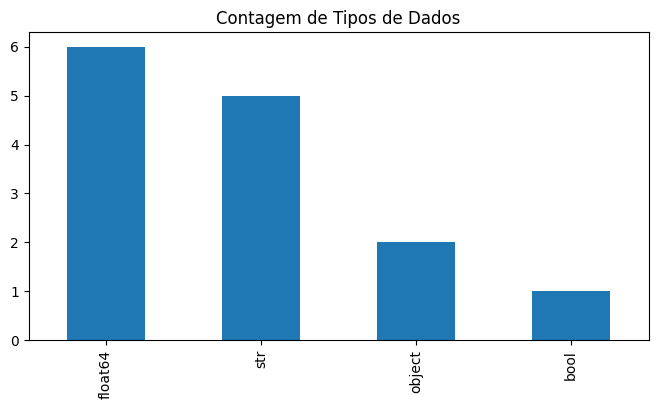

In [48]:
import pandas as pd

# 1. Visualizar os tipos de dados e valores nulos
print("### Tipos de Variáveis no Dataset ###")
print(train_df.dtypes)
print("-" * 30)

# 2. Separar as variáveis automaticamente
# Selecionamos 'object' e 'bool' para categóricas e o restante para numéricas
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train_df.select_dtypes(include=['object', 'bool']).columns.tolist()

# 3. Remover o Target (Transported) da lista de features, se ele estiver lá
if 'Transported' in categorical_cols:
    categorical_cols.remove('Transported')
if 'Transported' in numerical_cols:
    numerical_cols.remove('Transported')

# 4. Exibir o resultado da separação
print(f"Variáveis Numéricas ({len(numerical_cols)}): {numerical_cols}")
print(f"Variáveis Categóricas ({len(categorical_cols)}): {categorical_cols}")

# Opcional: Um gráfico rápido para ver a distribuição dos tipos
train_df.dtypes.value_counts().plot(kind='bar', title='Contagem de Tipos de Dados', figsize=(8, 4))
# Mostra quantas categorias únicas existem em cada coluna
print("Quantidade de dados unicos em cada coluna:",train_df.nunique())

## 1.2 Missing Data

In [49]:
# porcentagem de nulos em cada coluna 
missing_values = train_df.isnull().mean() * 100
print("Missing values (%):")
print(missing_values)

Missing values (%):
PassengerId     0.000000
HomePlanet      2.448644
CryoSleep       2.415776
Cabin           2.267872
Destination     2.284306
Age             2.021364
VIP             2.366475
RoomService     2.119967
FoodCourt       2.202136
ShoppingMall    2.185703
Spa             2.103533
VRDeck          2.185703
Name            2.366475
Transported     0.000000
dtype: float64


## Tratando nulos

In [50]:
# ==========================================
# 1. TRATAMENTOS LÓGICOS E ABSOLUTOS
# ==========================================
# Preencher gastos com 0 para quem está em CryoSleep
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in spending_cols:
    train_df.loc[(train_df['CryoSleep'] == True) & (train_df[col].isnull()), col] = 0

# Preencher CryoSleep com False para quem teve gastos
train_df.loc[(train_df['CryoSleep'].isnull()) & (train_df[spending_cols].sum(axis=1) > 0), 'CryoSleep'] = False


# ==========================================
# 2. TRATAMENTOS ESPECÍFICOS E "CABINE FANTASMA"
# ==========================================
# VIP: Preencher com False (Moda quase absoluta)
train_df['VIP'] = train_df['VIP'].fillna(False)

# Name: Preencher com Unknown
train_df['Name'] = train_df['Name'].fillna('Unknown')

# Cabin: A "Cabine Fantasma" (Z/9999/Z) 
# Feito ANTES de qualquer outro tratamento para isolar os desconhecidos
train_df['Cabin'] = train_df['Cabin'].fillna('Z/9999/Z')


# ==========================================
# 3. IMPUTAÇÃO AGRUPADA (INTELIGENTE)
# ==========================================
# Primeiro, extraímos o Grupo do PassengerId
train_df['Group'] = train_df['PassengerId'].apply(lambda x: x.split('_')[0])

# Imputando HomePlanet baseado no Grupo (A moda dentro do mesmo grupo)
train_df['HomePlanet'] = train_df.groupby('Group')['HomePlanet'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)

# Imputando Destination baseado no Grupo
train_df['Destination'] = train_df.groupby('Group')['Destination'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)

# Imputando Age baseado na mediana do HomePlanet
train_df['Age'] = train_df.groupby('HomePlanet')['Age'].transform(
    lambda x: x.fillna(x.median())
)


# ==========================================
# 4. REDE DE SEGURANÇA (FALLBACK GLOBAL)
# ==========================================
# Aplicamos as listas de colunas geradas no início (numerical_cols / categorical_cols)
# para preencher qualquer valor que tenha escapado das lógicas acima.

# Numéricas: Mediana (cobre gastos de quem não estava em CryoSleep e Idades isoladas)
for col in numerical_cols:
    train_df[col] = train_df[col].fillna(train_df[col].median())

# Categóricas: Moda (cobre CryoSleep, HomePlanet ou Destination residuais)
for col in categorical_cols:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

# Validação Final
print("Nulos restantes:\n", train_df.isnull().sum().sum())

Nulos restantes:
 0


# 2. EDA(Exploratory Data Analysis)

Text(0.5, 1.0, 'Correlation Heatmap')

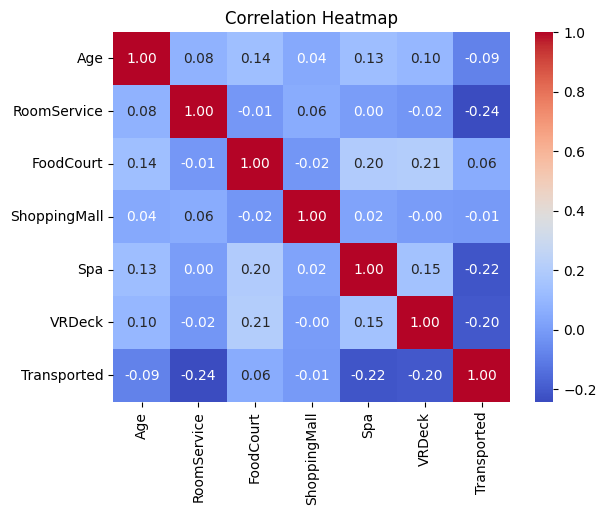

In [51]:
 
corr = train_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")

## Comportamento das variáveis categóricas

In [52]:
import altair as alt
import pandas as pd

# 0. Desabilitar o limite de linhas do Altair
alt.data_transformers.disable_max_rows()

# 1. Definir as colunas categóricas que queremos analisar no dropdown
cat_features = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP']

# 2. Transformar o DataFrame para o formato "Longo" (Melt)
df_cat_melted = train_df.melt(
    id_vars=['Transported'], 
    value_vars=cat_features,
    var_name='Feature', 
    value_name='Categoria'
)

# --- O FIX DA LEITURA (Tradução e Desambiguação) ---
# Transforma as categorias booleanas em Sim/Não
df_cat_melted['Categoria'] = df_cat_melted['Categoria'].astype(str).replace({
    'True': 'True', 
    'False': 'False'
})

# Transforma o Target da legenda 
df_cat_melted['Transported'] = df_cat_melted['Transported'].astype(str).replace({
    'True': 'Transportado (Sim)', 
    'False': 'Ficou (Não)'
})
# ----------------------------------------------------

# 3. Criar a interatividade (Menu Dropdown)
dropdown_cat = alt.binding_select(options=cat_features, name='Feature Categórica: ')
selection_cat = alt.selection_point(fields=['Feature'], bind=dropdown_cat, value=cat_features[0])

# 4. Construir o Gráfico (Lado a Lado por Contagem)
chart_cat = alt.Chart(df_cat_melted).mark_bar().encode(
    x=alt.X('Categoria:N', title='Categorias da Feature'),
    
    # xOffset coloca as barras de Transported lado a lado
    xOffset='Transported:N', 
    
    # Eixo Y como contagem simples
    y=alt.Y('count():Q', title='Contagem de Passageiros'),
    
    # Cores
    color=alt.Color('Transported:N', title='Status', scale=alt.Scale(scheme='set1')),
    
    # Tooltip (o que aparece ao passar o mouse)
    tooltip=['Categoria:N', 'Transported:N', 'count():Q']
).add_params(
    selection_cat
).transform_filter(
    selection_cat
).properties(
    width=600,
    height=400,
    title='Análise: Features Categóricas vs Transported (Contagem Absoluta)'
).interactive()

# Exibir o gráfico
chart_cat

alt.Chart(...)

## Comportamento das variáveis numéricas

In [53]:
# 1. Definir as colunas numéricas para o dropdown
num_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 2. Transformar para o formato "Longo"
df_num_melted = train_df.melt(
    id_vars=['Transported'], 
    value_vars=num_features,
    var_name='Feature', 
    value_name='Valor_Numerico'
)

# --- O FIX DA LEITURA (Igual fizemos no outro) ---
df_num_melted['Transported'] = df_num_melted['Transported'].astype(str).replace({
    'True': 'Transportado (Sim)', 
    'False': 'Ficou (Não)'
})
# ------------------------------------------------

# 3. Criar a interatividade
dropdown_num = alt.binding_select(options=num_features, name='Feature Numérica: ')
selection_num = alt.selection_point(fields=['Feature'], bind=dropdown_num, value=num_features[0])

# 4. Construir o Histograma (À prova de falhas e perfeito para ver concentrações)
chart_num = alt.Chart(df_num_melted).mark_bar(opacity=0.6).encode(
    # Dividimos os valores em "bins" (faixas) para criar o histograma
    x=alt.X('Valor_Numerico:Q', bin=alt.Bin(maxbins=40), title='Valor da Feature'),
    
    # stack=None faz com que as barras azul e vermelha fiquem sobrepostas (transparentes)
    y=alt.Y('count():Q', stack=None, title='Contagem de Passageiros'),
    
    color=alt.Color('Transported:N', title='Status', scale=alt.Scale(scheme='set1')),
    tooltip=['count():Q', 'Transported:N']
).add_params(
    selection_num
).transform_filter(
    selection_num
).properties(
    width=600,
    height=400,
    title='Distribuição: Features Numéricas vs Transported'
).interactive() # O interactive() funciona perfeitamente aqui no histograma!

chart_num

alt.Chart(...)

## 3. Identify target and predictors


In [54]:
# Splitting PassengerId into Group and GroupNumber
train_df[['Group', 'GroupNumber']] = train_df['PassengerId'].str.split('_', expand=True).astype(int)

# Splitting Cabin into Deck, Number, and Side
train_df[['CabinDeck', 'CabinNum', 'CabinSide']] = train_df['Cabin'].str.split('/', expand=True)

# Convert CabinNum to numeric since it represents a position
train_df['CabinNum'] = train_df['CabinNum'].astype(float)

# Split Name by space and take the last element
train_df['Surname'] = train_df['Name'].str.split(' ').str[-1]

amenities = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
# Fill NAs with 0 just for the sum calculation
#train_df['TotalSpend'] = train_df[amenities].fillna(0).sum(axis=1)

# Calculate how many people share the same Group ID
group_counts = train_df['Group'].value_counts()
train_df['GroupSize'] = train_df['Group'].map(group_counts)

# Create a binary feature for passengers traveling alone
train_df['IsAlone'] = (train_df['GroupSize'] == 1).astype(float)

# Create an AgeGroup category using pandas cut
# Bins: 0-12 (Child), 13-17 (Teen), 18-59 (Adult), 60+ (Senior)
train_df['AgeGroup'] = pd.cut(
    train_df['Age'], 
    bins=[-1, 12, 17, 59, 150], 
    labels=['Child', 'Teen', 'Adult', 'Senior']
)

# Create a binary flag for passengers who spent absolutely nothing
#train_df['ZeroSpend'] = (train_df['TotalSpend'] == 0).astype(float)

# Removing columns that won't be used for training
train_df.drop(['PassengerId', 'Name', 'Cabin'], axis=1, inplace=True)
train_df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Group,GroupNumber,CabinDeck,CabinNum,CabinSide,Surname,GroupSize,IsAlone,AgeGroup
0,Earth,True,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,0.0,False,3652,1,G,591.0,S,Frandriquez,1,1.0,Adult
1,Europa,False,55 Cancri e,32.0,False,0.0,2154.0,0.0,9655.0,859.0,False,8449,1,C,317.0,S,Purellliss,1,1.0,Adult
2,Europa,False,TRAPPIST-1e,31.0,False,0.0,1983.0,0.0,172.0,52.0,True,1871,1,C,70.0,S,Spedlybood,1,1.0,Adult
3,Earth,True,PSO J318.5-22,25.0,False,0.0,0.0,0.0,0.0,0.0,True,1811,1,G,285.0,S,Georgasey,2,0.0,Adult
4,Europa,False,55 Cancri e,26.0,False,6.0,728.0,0.0,1273.0,1116.0,False,8589,1,D,267.0,P,Gealter,1,1.0,Adult


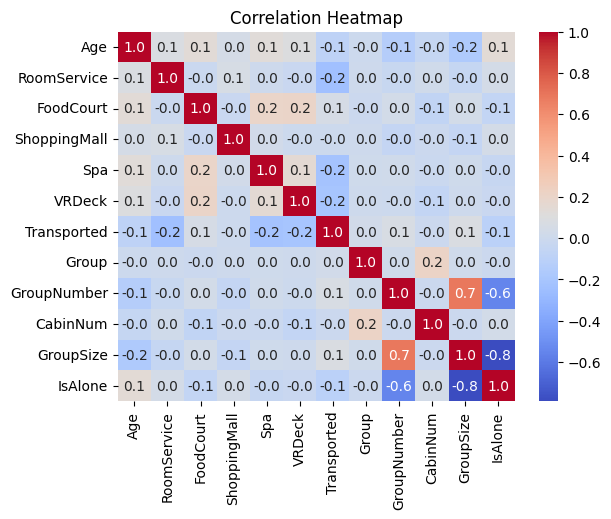

In [55]:
corr = train_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".1f")
plt.title("Correlation Heatmap")
plt.show()

In [56]:
target_col = "Transported"
id_col = "PassengerId"

X = train_df.drop(columns=[target_col])
y = train_df[target_col].copy()

print("Target summary:")
display(y.describe())


Target summary:


count     6085
unique       2
top       True
freq      3065
Name: Transported, dtype: object

## 3. Build a local validation split

Use this split to compare models **before** submitting to the leaderboard.


In [57]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_valid.shape)


(4868, 19) (1217, 19)


## 4. Separate numeric and categorical columns


In [58]:
num_cols = ['Age', 'TotalSpend', 'Group', 'CabinNum', 'GroupSize']
cat_cols = ['HomePlanet', 'Destination', 'CabinDeck', 'CabinSide', 'Surname', 'AgeGroup'] 
bin_cols = ['CryoSleep', 'VIP', 'IsAlone', 'ZeroSpend']

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))
print("Binary features:", len(bin_cols))

X_train.info()


Numeric features: 5
Categorical features: 6
Binary features: 4
<class 'pandas.DataFrame'>
Index: 4868 entries, 3856 to 860
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   HomePlanet    4868 non-null   str     
 1   CryoSleep     4868 non-null   object  
 2   Destination   4868 non-null   str     
 3   Age           4868 non-null   float64 
 4   VIP           4868 non-null   object  
 5   RoomService   4868 non-null   float64 
 6   FoodCourt     4868 non-null   float64 
 7   ShoppingMall  4868 non-null   float64 
 8   Spa           4868 non-null   float64 
 9   VRDeck        4868 non-null   float64 
 10  Group         4868 non-null   int64   
 11  GroupNumber   4868 non-null   int64   
 12  CabinDeck     4868 non-null   str     
 13  CabinNum      4868 non-null   float64 
 14  CabinSide     4868 non-null   str     
 15  Surname       4868 non-null   object  
 16  GroupSize     4868 non-null   int64   
 17  IsA

## 5. Create a preprocessing pipeline

You may improve this pipeline as part of the assignment.


In [59]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

binary_transformer =  Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
    ("bin", binary_transformer, bin_cols)
])


## 6. Baseline model

Start with a simple model.


In [60]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)
pred_valid_baseline = baseline_model.predict(X_valid)

acc_baseline = accuracy_score(y_valid, pred_valid_baseline)
f1_baseline = f1_score(y_valid, pred_valid_baseline, average='macro')


print("Baseline Accuracy:", acc_baseline)
print("Baseline F1-Score:", f1_baseline)



ValueError: A given column is not a column of the dataframe

## 7. Improved model

Try at least one stronger model and compare the result.


In [ ]:
from xgboost import XGBClassifier


improved_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",   XGBClassifier(subsample=0.7, 
    n_estimators=1500,
    min_child_weight=1,
    max_depth=3,
    learning_rate=0.03,
    colsample_bytree=0.8
    ))
])

improved_model.fit(X_train, y_train)
pred_valid_improved = improved_model.predict(X_valid)

acc_improved = accuracy_score(y_valid, pred_valid_improved)
f1_improved = f1_score(y_valid, pred_valid_improved, average='macro')


print("Improved Accuracy:", acc_improved)
print("Improved F1-Score:", f1_improved)



## 8. Compare models

Briefly discuss the difference between the baseline and the improved model.


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Improved"],
    "Accuracy": [acc_baseline, acc_improved],
    "F1-Score": [f1_baseline, f1_improved],

})

comparison


**Write a short discussion here.**

- Which model performed better?
- Was the improvement large or small?
- What might explain the difference?


## 9. Train the final model on the full student training set

Choose your final model and fit it using all available labeled data.


In [ ]:
# Apply the same logic to test_df
test_df[['Group', 'GroupNumber']] = test_df['PassengerId'].str.split('_', expand=True).astype(int)
test_df['Cabin'] = test_df['Cabin'].fillna('None/0/None')
test_df[['CabinDeck', 'CabinNum', 'CabinSide']] = test_df['Cabin'].str.split('/', expand=True)
test_df['CabinNum'] = test_df['CabinNum'].astype(float)

# Amenities and Surname
test_df['TotalSpend'] = test_df[amenities].fillna(0).sum(axis=1)
test_df['Surname'] = test_df['Name'].str.split(' ').str[-1]

# Add the missing advanced features to test_df
group_counts_test = test_df['Group'].value_counts()
test_df['GroupSize'] = test_df['Group'].map(group_counts_test)
test_df['IsAlone'] = (test_df['GroupSize'] == 1).astype(float)

test_df['AgeGroup'] = pd.cut(
    test_df['Age'], 
    bins=[-1, 12, 17, 59, 150], 
    labels=['Child', 'Teen', 'Adult', 'Senior']
)
test_df['ZeroSpend'] = (test_df['TotalSpend'] == 0).astype(float)

# Keep the PassengerId somewhere for the submission file before dropping it!
test_ids = test_df['PassengerId'].copy() 
test_df.drop(['PassengerId', 'Name', 'Cabin'], axis=1, inplace=True)

In [ ]:
final_model = improved_model  # change if needed

# Fit on the entire training dataset
final_model.fit(X, y)

# Predict on the properly formatted test set
test_predictions = final_model.predict(test_df)

# Create the submission file using test_ids!
submission = pd.DataFrame({
    id_col: test_ids, 
    "prediction": test_predictions # Make sure the target name matches Kaggle's expected format
})

submission.head()

## 10. Save the submission file


In [ ]:
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")


## 11. Submit to the leaderboard

Upload `submission.csv` to:

<https://(Enter your Streamlit app URL here)/>

After submitting, record your score below.


**Leaderboard score(s):**

- First submission:
- Best submission:
- Final submitted model:


## 12. Final reflection

Write a short final reflection addressing:

- what preprocessing choices were most important
- whether feature engineering helped
- what model worked best for your group
- what you would try next if you had more time


**Write your final reflection here.**


## 📤 Final Deliverables Checklist

Before submitting your work, verify that you are delivering:

- [ ] completed notebook
- [ ] generated submission file
- [ ] leaderboard score recorded
- [ ] short discussion of preprocessing and model choices
- [ ] final reflection
